In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [3]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
order_payments = pd.read_csv("order_payment.csv")
products = pd.read_csv("products.csv")
products_translation = pd.read_csv("product_translation.csv")

In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273.0,osasco,SP
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550.0,itapecerica,MG
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830.0,nova venecia,ES
3,0002414f95344307404f0ace7a26f1d5,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664.0,mendonca,MG
4,000379cdec625522490c315e70c7a9fb,0b83f73b19c2019e182fd552c048a22c,4841.0,sao paulo,SP


In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,9/13/2017 8:59,9/13/2017 9:45,9/19/2017 18:34,9/20/2017 23:43,9/29/2017 0:00
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,4/26/2017 10:53,4/26/2017 11:05,5/4/2017 14:35,5/12/2017 16:04,5/15/2017 0:00
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,1/14/2018 14:33,1/14/2018 14:48,1/16/2018 12:36,1/22/2018 13:19,2/5/2018 0:00
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,8/8/2018 10:00,8/8/2018 10:10,8/10/2018 13:28,8/14/2018 13:32,8/20/2018 0:00
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2/4/2017 13:57,2/4/2017 14:10,2/16/2017 9:46,3/1/2017 16:42,3/17/2017 0:00


In [9]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,9/19/2017 9:45,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,5/3/2017 11:05,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,1/18/2018 14:48,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,8/15/2018 10:10,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2/13/2017 13:57,199.90,18.14


In [11]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [13]:
products.head()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4.0,625.0,20.0,17.0,13.0


In [15]:
products_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [27]:
#customers.shape
#orders.shape
#order_items.shape
#order_payments.shape
#products.shape
products_translation.shape

(71, 2)

In [57]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91895 entries, 0 to 91894
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               91895 non-null  object 
 1   customer_unique_id        91895 non-null  object 
 2   customer_zip_code_prefix  91894 non-null  float64
 3   customer_city             91894 non-null  object 
 4   customer_state            91894 non-null  object 
dtypes: float64(1), object(4)
memory usage: 3.5+ MB


In [59]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49956 entries, 0 to 49955
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       49956 non-null  object
 1   customer_id                    49956 non-null  object
 2   order_status                   49956 non-null  object
 3   order_purchase_timestamp       49955 non-null  object
 4   order_approved_at              49868 non-null  object
 5   order_delivered_carrier_date   49053 non-null  object
 6   order_delivered_customer_date  48465 non-null  object
 7   order_estimated_delivery_date  49955 non-null  object
dtypes: object(8)
memory usage: 3.0+ MB


In [61]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41954 entries, 0 to 41953
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             41954 non-null  object 
 1   order_item_id        41954 non-null  int64  
 2   product_id           41954 non-null  object 
 3   seller_id            41953 non-null  object 
 4   shipping_limit_date  41953 non-null  object 
 5   price                41953 non-null  float64
 6   freight_value        41953 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 2.2+ MB


In [63]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67988 entries, 0 to 67987
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              67988 non-null  object 
 1   payment_sequential    67988 non-null  int64  
 2   payment_type          67988 non-null  object 
 3   payment_installments  67988 non-null  int64  
 4   payment_value         67988 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.6+ MB


In [65]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29567 entries, 0 to 29566
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  29567 non-null  object 
 1   product_category_name       29567 non-null  object 
 2   product_name_length         29567 non-null  int64  
 3   product_description_length  29567 non-null  int64  
 4   product_photos_qty          29566 non-null  float64
 5   product_weight_g            29566 non-null  float64
 6   product_length_cm           29566 non-null  float64
 7   product_height_cm           29566 non-null  float64
 8   product_width_cm            29566 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 2.0+ MB


In [67]:
products_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [69]:
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype('Int64').astype(str)

In [71]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [73]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [75]:
products['product_photos_qty'] = products['product_photos_qty'].astype('Int64')

In [85]:
#customers.info()
#order_items.info()
#products.info()
#products_translation.info()
#order_payments.info()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49956 entries, 0 to 49955
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       49956 non-null  object        
 1   customer_id                    49956 non-null  object        
 2   order_status                   49956 non-null  object        
 3   order_purchase_timestamp       49955 non-null  datetime64[ns]
 4   order_approved_at              49868 non-null  datetime64[ns]
 5   order_delivered_carrier_date   49053 non-null  datetime64[ns]
 6   order_delivered_customer_date  48465 non-null  datetime64[ns]
 7   order_estimated_delivery_date  49955 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 3.0+ MB


In [51]:
customers.describe()
#orders.describe()
#order_items.describe()
#order_payments.describe()
#products.describe()
#products_translation.describe()

,customer_zip_code_prefix
count,91894.000000
mean,35106.066490
std,29787.631061
min,1003.000000
25%,11320.000000
50%,24360.000000
75%,58900.000000
max,99980.000000


In [89]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               1
customer_state              1
dtype: int64

In [91]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            1
order_approved_at                  88
order_delivered_carrier_date      903
order_delivered_customer_date    1491
order_estimated_delivery_date       1
dtype: int64

In [93]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              1
shipping_limit_date    1
price                  1
freight_value          1
dtype: int64

In [95]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_length           0
product_description_length    0
product_photos_qty            1
product_weight_g              1
product_length_cm             1
product_height_cm             1
product_width_cm              1
dtype: int64

In [97]:
order_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [99]:
products_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [101]:
customers = customers.dropna()

In [103]:
orders = orders.dropna(subset=['order_purchase_timestamp'])

In [105]:
order_items = order_items.dropna()

In [107]:
products.fillna(products.median(numeric_only=True), inplace=True)

In [121]:
customers.duplicated().sum()
orders.duplicated().sum()
order_items.duplicated().sum()
products.duplicated().sum()
products_translation.duplicated().sum()
order_payments.duplicated().sum()

0

In [ ]:
## Table Merge ###

In [123]:
df = orders.merge(customers, on='customer_id', how='left')

In [125]:
df = df.merge(order_items, on='order_id', how='left')

In [127]:
df = df.merge(order_payments, on='order_id', how='left')

In [129]:
df = df.merge(products, on='product_id', how='left')

In [131]:
df.shape

(56490, 30)

In [135]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,payment_value,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:00,2017-09-13 09:45:00,2017-09-19 18:34:00,2017-09-20 23:43:00,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,...,NaN,NaN,cool_stuff,58.0,598.0,4,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:00,2017-04-26 11:05:00,2017-05-04 14:35:00,2017-05-12 16:04:00,2017-05-15,NaN,NaN,...,3.0,259.83,pet_shop,56.0,239.0,2,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:00,2018-01-14 14:48:00,2018-01-16 12:36:00,2018-01-22 13:19:00,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,...,5.0,216.87,moveis_decoracao,59.0,695.0,2,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:00,2018-08-08 10:10:00,2018-08-10 13:28:00,2018-08-14 13:32:00,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,...,2.0,25.78,perfumaria,42.0,480.0,1,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:00,2017-02-04 14:10:00,2017-02-16 09:46:00,2017-03-01 16:42:00,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,...,NaN,NaN,ferramentas_jardim,59.0,409.0,1,3750.0,35.0,40.0,30.0


In [137]:
df.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   89
order_delivered_carrier_date      1014
order_delivered_customer_date     1648
order_estimated_delivery_date        0
customer_unique_id                4196
customer_zip_code_prefix          4196
customer_city                     4196
customer_state                    4196
order_item_id                    13537
product_id                       13537
seller_id                        13537
shipping_limit_date              13537
price                            13537
freight_value                    13537
payment_sequential               18534
payment_type                     18534
payment_installments             18534
payment_value                    18534
product_category_name            17812
product_name_length              17812
product_description_length       17812
product_photos_qty       

In [139]:
df = df.dropna(subset=['customer_unique_id'])

In [141]:
df = df.dropna(subset=['product_id'])

In [143]:
df = df.dropna(subset=['payment_value'])

In [145]:
df = df.dropna(subset=['product_category_name'])

In [147]:
df.shape

(24086, 30)

In [149]:
df.isnull().sum()

order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  5
order_delivered_carrier_date     248
order_delivered_customer_date    519
order_estimated_delivery_date      0
customer_unique_id                 0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
payment_sequential                 0
payment_type                       0
payment_installments               0
payment_value                      0
product_category_name              0
product_name_length                0
product_description_length         0
product_photos_qty                 0
product_weight_g                   0
p

In [151]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [153]:
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

In [155]:
df['total_order_value'] = df['price'] + df['freight_value']

In [157]:
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()

df['customer_type'] = df['customer_unique_id'].map(
    lambda x: 'Repeat' if customer_orders[x] > 1 else 'One-time'
)

In [161]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_month,delivery_days,total_order_value,customer_type
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:00,2018-01-14 14:48:00,2018-01-16 12:36:00,2018-01-22 13:19:00,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,...,695.0,2,3050.0,33.0,13.0,33.0,2018-01,7.0,216.87,One-time
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:00,2018-08-08 10:10:00,2018-08-10 13:28:00,2018-08-14 13:32:00,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,...,480.0,1,200.0,16.0,10.0,15.0,2018-08,6.0,25.78,One-time
5,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:00,2017-05-17 03:55:00,2017-05-17 11:05:00,2017-05-22 13:44:00,2017-06-06,85c835d128beae5b4ce8602c491bf385,38017,...,558.0,1,450.0,24.0,8.0,15.0,2017-05,6.0,34.59,One-time
6,00054e8431b9d7675808bcb819fb4a32,32e2e6ab09e778d99bf2e0ecd4898718,delivered,2017-12-10 11:53:00,2017-12-10 12:10:00,2017-12-12 01:07:00,2017-12-18 22:03:00,2018-01-04,635d9ac1680f03288e72ada3a1035803,16700,...,815.0,1,200.0,27.0,5.0,20.0,2017-12,8.0,31.75,One-time
7,000576fe39319847cbb9d288c5617fa6,9ed5e522dd9dd85b4af4a077526d8117,delivered,2018-07-04 12:08:00,2018-07-05 16:35:00,2018-07-05 12:15:00,2018-07-09 14:04:00,2018-07-25,fda4476abb6307ab3c415b7e6d026526,11702,...,1310.0,3,13805.0,35.0,75.0,45.0,2018-07,5.0,880.75,One-time


In [163]:
df[['order_month','delivery_days','total_order_value','customer_type']].head()

,order_month,delivery_days,total_order_value,customer_type
2,2018-01,7.0,216.87,One-time
3,2018-08,6.0,25.78,One-time
5,2017-05,6.0,34.59,One-time
6,2017-12,8.0,31.75,One-time
7,2018-07,5.0,880.75,One-time


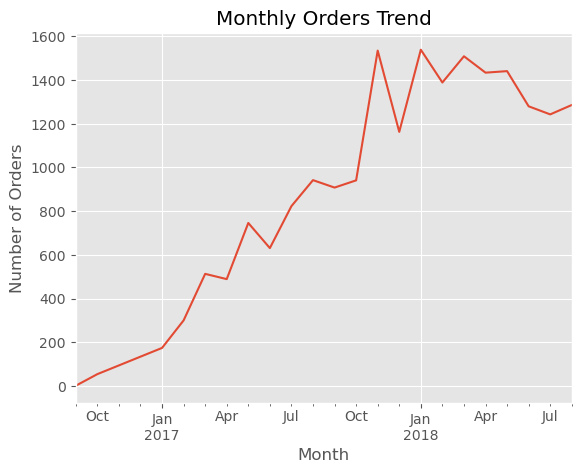

In [165]:
#Monthly Orders Trend
monthly_orders = df.groupby('order_month')['order_id'].nunique()
monthly_orders.plot()
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

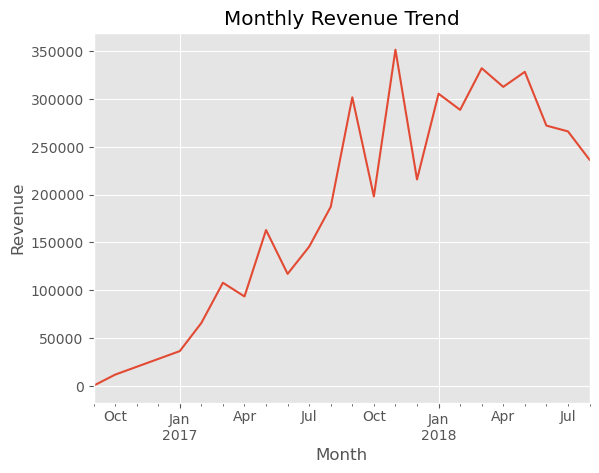

In [167]:
#Monthly Revenue Trend
monthly_revenue = df.groupby('order_month')['payment_value'].sum()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [171]:
df = df.merge(products_translation, 
              on='product_category_name', 
              how='left')

In [175]:
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')

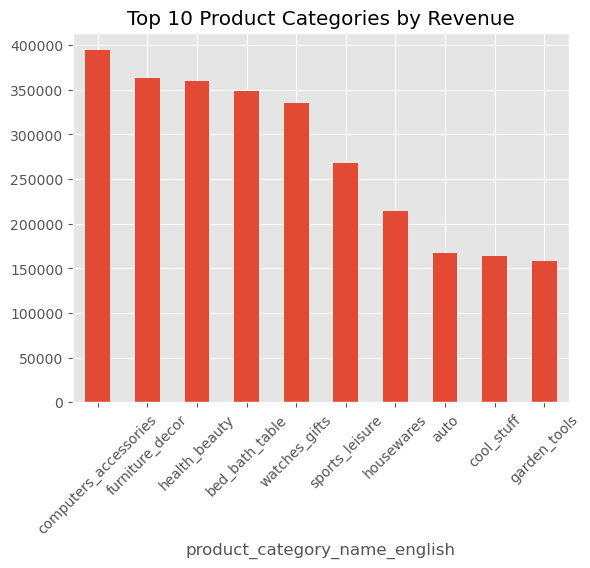

In [179]:
top_categories = df.groupby('product_category_name_english')['payment_value'] \
                   .sum() \
                   .sort_values(ascending=False) \
                   .head(10)

top_categories.plot(kind='bar')
plt.title("Top 10 Product Categories by Revenue")
plt.xticks(rotation=45)
plt.show()

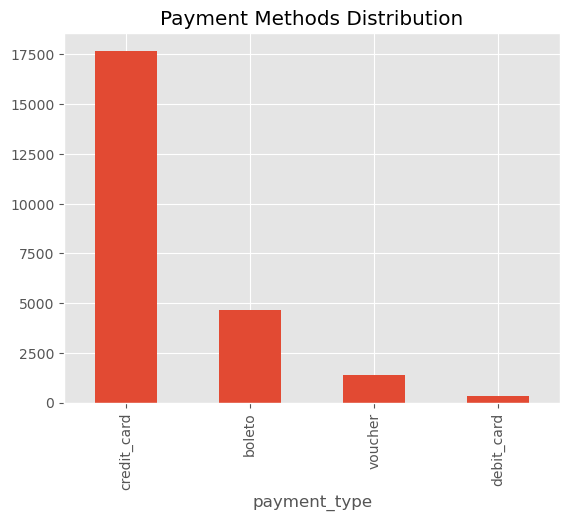

In [181]:
#Payment Method Distribution
df['payment_type'].value_counts().plot(kind='bar')
plt.title("Payment Methods Distribution")
plt.show()

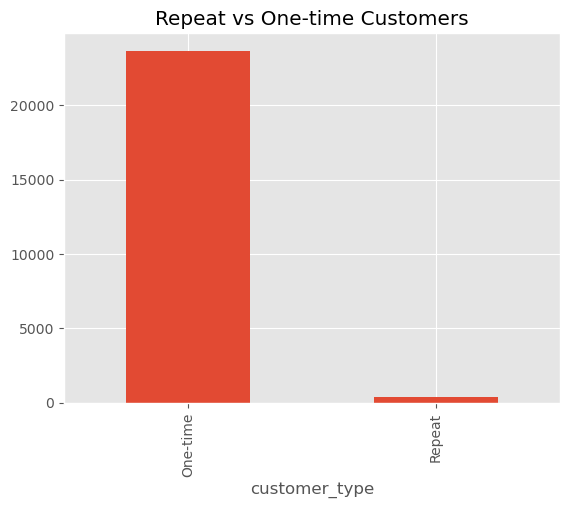

In [183]:
#Customer Type Distribution
df['customer_type'].value_counts().plot(kind='bar')
plt.title("Repeat vs One-time Customers")
plt.show()

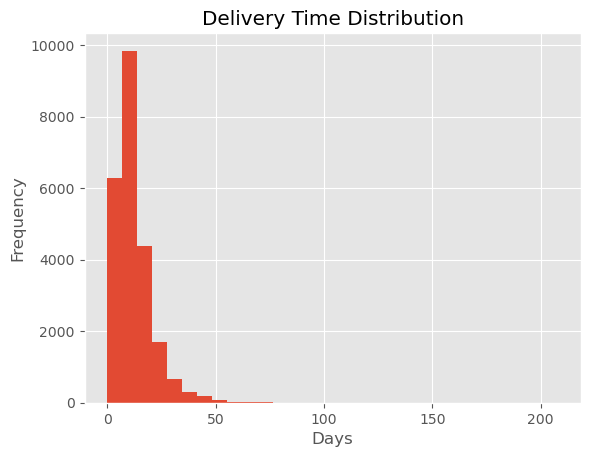

In [185]:
#Delivery Time Distribution
df['delivery_days'].dropna().plot(kind='hist', bins=30)
plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.show()

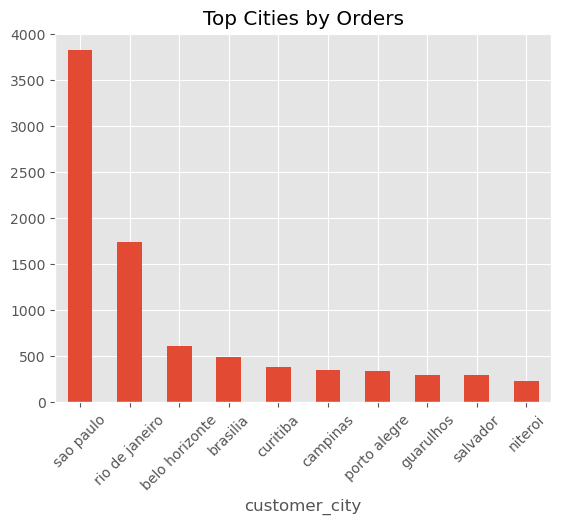

In [187]:
#Top Cities by Orders
top_cities = df['customer_city'].value_counts().head(10)
top_cities.plot(kind='bar')
plt.title("Top Cities by Orders")
plt.xticks(rotation=45)
plt.show()

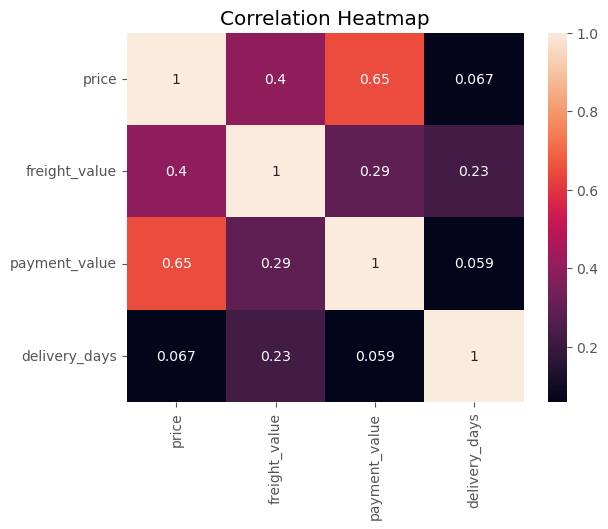

In [189]:
#Correlation Heatmap
corr = df[['price','freight_value','payment_value','delivery_days']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [191]:
df.to_csv("final_dataset.csv", index=False)